# Phân tích RFM & Kỹ nghệ đặc trưng (Feature Engineering) - Ngành Bán Lẻ Điện Thoại
**Thực hiện:** Thành viên B (Data Analyst)  
**Mục tiêu:** Trích xuất các đặc trưng hành vi khách hàng từ lịch sử giao dịch thô (Recency, Frequency, Monetary) và các chỉ số đặc thù của ngành di động (Tỷ lệ mua Flagship, Tỷ lệ mua phụ kiện...).

In [ ]:
# notebooks\01_rfm_analysis
# Import các thư viện cần thiết
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import os

# Cấu hình hiển thị biểu đồ
%matplotlib inline
sns.set_theme(style="whitegrid")

# Khắc phục lỗi đường dẫn (Tự động tìm thư mục gốc)
current_dir = os.getcwd()
if 'notebooks' in current_dir:
    base_dir = os.path.dirname(current_dir) # Lùi 1 cấp nếu đang ở trong notebooks/
else:
    base_dir = current_dir

file_path = os.path.join(base_dir, 'data', 'raw', 'mobile_sales_raw.csv')
print(f"Đang đọc dữ liệu từ: {file_path}")

# Load dữ liệu
df = pd.read_csv(file_path)
df['order_date'] = pd.to_datetime(df['order_date'])

print(f"Kích thước tập dữ liệu: {df.shape}")
df.head()

Đang đọc dữ liệu từ: d:\CDIO\mobile-clv-prediction\data\raw\mobile_sales_raw.csv
Kích thước tập dữ liệu: (2500, 10)


,order_id,customer_id,order_date,brand,category,product_name,quantity,unit_price,total_price,is_installment
0,ORD00362,CUS0242,2022-01-01,Oppo,Flagship,Find N3 Flip,1,25000000,25000000,1
1,ORD02396,CUS0158,2022-01-01,Apple,Mid-range,iPhone 11,1,10000000,10000000,1
2,ORD00872,CUS0367,2022-01-01,Oppo,Flagship,Find N3 Flip,1,25000000,25000000,1
3,ORD00062,CUS0128,2022-01-01,Apple,Mid-range,iPhone 13,1,15000000,15000000,0
4,ORD00191,CUS0013,2022-01-01,Oppo,Mid-range,Reno 11,1,10000000,10000000,1


## 1. Tính toán RFM Cơ bản
http://googleusercontent.com/image_content/175


* **Recency (R):** Số ngày kể từ lần mua hàng cuối cùng. (Càng nhỏ càng tốt)
* **Frequency (F):** Tổng số đơn hàng. (Càng lớn càng tốt)
* **Monetary (M):** Tổng số tiền khách đã chi. (Càng lớn càng tốt)

In [2]:
# Giả định "ngày hiện tại" là ngày sau giao dịch cuối cùng trong data 1 ngày
snapshot_date = df['order_date'].max() + pd.Timedelta(days=1)

# Tính RFM
rfm = df.groupby('customer_id').agg({
    'order_date': lambda x: (snapshot_date - x.max()).days, # Recency
    'order_id': 'nunique',                                  # Frequency (Số đơn hàng duy nhất)
    'total_price': 'sum'                                    # Monetary
}).reset_index()

# Đổi tên cột cho chuẩn
rfm.rename(columns={
    'order_date': 'Recency',
    'order_id': 'Frequency',
    'total_price': 'Monetary'
}, inplace=True)

rfm.head()

,customer_id,Recency,Frequency,Monetary
0,CUS0001,124,3,56990000
1,CUS0002,111,13,139000000
2,CUS0003,95,14,207800000
3,CUS0004,18,4,64000000
4,CUS0005,57,3,53500000


## 2. Kỹ nghệ đặc trưng Nâng cao (Advanced Feature Engineering)
Ngành điện thoại có những đặc thù riêng. Một khách hàng mua 5 cái ốp lưng (Frequency = 5) không thể có giá trị bằng người mua 2 cái iPhone (Frequency = 2). Do đó, ta cần tạo thêm:
1. **Accessory_Ratio:** Tỷ lệ mua phụ kiện (Đo lường sự gắn kết).
2. **Flagship_Ratio:** Tỷ lệ mua dòng máy cao cấp (Đo lường khả năng chi trả).
3. **Installment_Rate:** Tỷ lệ mua trả góp.
4. **Favorite_Brand:** Thương hiệu mua nhiều nhất.

In [3]:
# 1. Phân tích chi tiết từng giỏ hàng của khách
customer_details = df.groupby('customer_id').agg(
    total_items=('quantity', 'sum'),
    total_installment=('is_installment', 'sum')
).reset_index()

# 2. Tính Tỷ lệ trả góp (Installment Rate)
customer_details['Installment_Rate'] = customer_details['total_installment'] / customer_details['total_items']

# 3. Tính tỷ lệ mua Phụ kiện (Accessories) và Dòng cao cấp (Flagship)
category_counts = pd.crosstab(df['customer_id'], df['category'], normalize='index')
category_counts = category_counts.add_suffix('_Ratio').reset_index()

# Kiểm tra xem có cột Flagship/Accessories không để tránh lỗi
if 'Flagship_Ratio' not in category_counts.columns:
    category_counts['Flagship_Ratio'] = 0
if 'Accessories_Ratio' not in category_counts.columns:
    category_counts['Accessories_Ratio'] = 0

# 4. Tìm thương hiệu yêu thích nhất (Favorite Brand)
favorite_brand = df.groupby('customer_id')['brand'].agg(lambda x: x.mode()[0]).reset_index()
favorite_brand.rename(columns={'brand': 'Favorite_Brand'}, inplace=True)

# 5. Gộp tất cả các đặc trưng lại với nhau
features_df = rfm.merge(customer_details[['customer_id', 'Installment_Rate']], on='customer_id')
features_df = features_df.merge(category_counts[['customer_id', 'Flagship_Ratio', 'Accessories_Ratio']], on='customer_id', how='left')
features_df = features_df.merge(favorite_brand, on='customer_id')

# Làm tròn số
features_df = features_df.round(3)

print("Kích thước tập đặc trưng:", features_df.shape)
features_df.head()

Kích thước tập đặc trưng: (421, 8)


,customer_id,Recency,Frequency,Monetary,Installment_Rate,Flagship_Ratio,Accessories_Ratio,Favorite_Brand
0,CUS0001,124,3,56990000,0.667,0.667,0.333,Xiaomi
1,CUS0002,111,13,139000000,0.286,0.154,0.385,Samsung
2,CUS0003,95,14,207800000,0.267,0.286,0.357,Samsung
3,CUS0004,18,4,64000000,0.000,0.250,0.500,Samsung
4,CUS0005,57,3,53500000,0.333,0.333,0.333,Apple


## 3. Trực quan hóa dữ liệu (EDA) nhanh
Xem phân phối của Recency, Frequency và Monetary để kiểm tra xem dữ liệu có bị lệch (Skewed) hay không. (Thường dữ liệu bán lẻ sẽ bị lệch phải - Pareto 80/20).

d:\CDIO\.venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
d:\CDIO\.venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
d:\CDIO\.venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
d:\CDIO\.venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


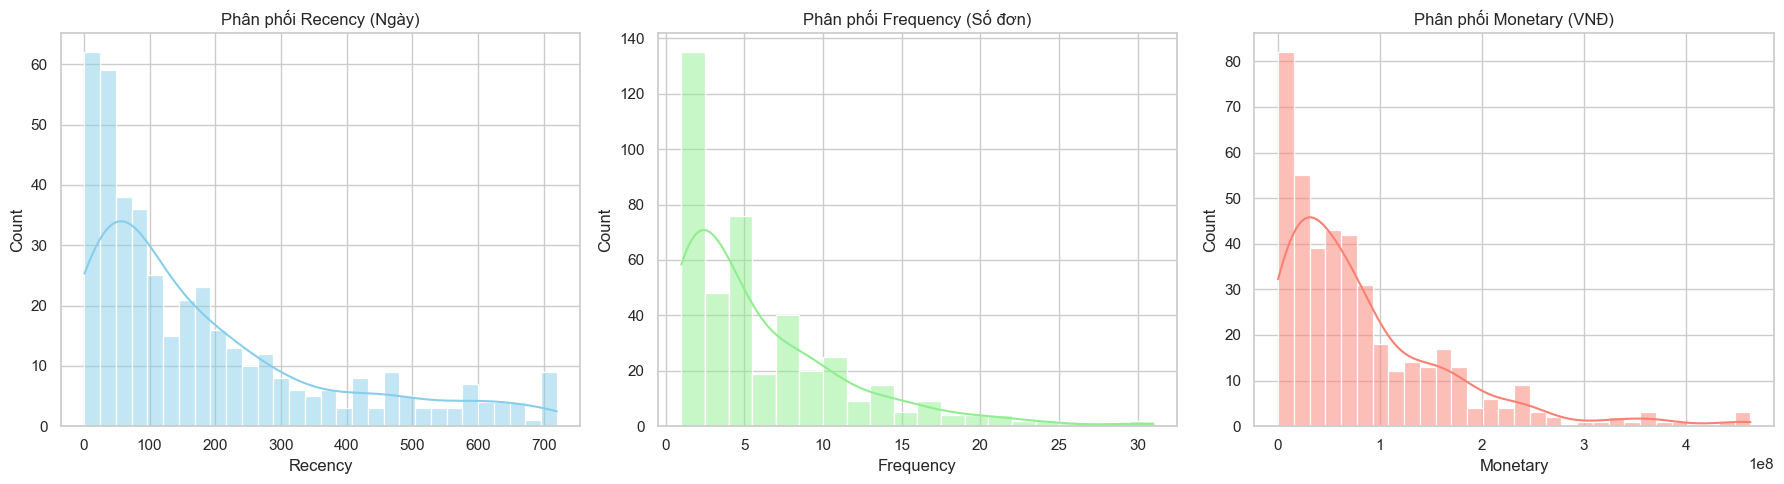

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(features_df['Recency'], bins=30, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Phân phối Recency (Ngày)')

sns.histplot(features_df['Frequency'], bins=20, kde=True, ax=axes[1], color='lightgreen')
axes[1].set_title('Phân phối Frequency (Số đơn)')

sns.histplot(features_df['Monetary'], bins=30, kde=True, ax=axes[2], color='salmon')
axes[2].set_title('Phân phối Monetary (VNĐ)')

plt.tight_layout()
plt.show()

## 4. Lưu dữ liệu đã xử lý
Lưu tập đặc trưng này vào thư mục `data/processed/` để Thành viên C và D sử dụng cho việc huấn luyện Machine Learning.

In [5]:
output_dir = os.path.join(base_dir, 'data', 'processed')
os.makedirs(output_dir, exist_ok=True) # Đảm bảo thư mục tồn tại

output_path = os.path.join(output_dir, 'customer_features.csv')
features_df.to_csv(output_path, index=False)

print(f"✅ Đã lưu tập đặc trưng thành công tại: {output_path}")

✅ Đã lưu tập đặc trưng thành công tại: d:\CDIO\mobile-clv-prediction\data\processed\customer_features.csv
